# Day 1: PTB-XL arrhythmia classifier
Runtime > Change runtime type > **T4 GPU**, then Run all (~20-30 min).

In [2]:
import torch; print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU')

Tesla T4


In [3]:
!nvidia-smi

Wed Oct  7 13:20:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
!pip -q install wfdb
if not os.path.exists('/content/MedTech-Suite'):
    !git clone -q https://github.com/aryan9-6-5/MedTech-Suite.git /content/MedTech-Suite
%cd /content/MedTech-Suite/day-1-ptbxl-arrhythmia-classifier


/content/MedTech-Suite/day-1-ptbxl-arrhythmia-classifier


In [5]:
# 100 Hz records + metadata from PhysioNet's public S3 mirror (~0.8 GB, parallel)
!pip -q install awscli
# Boost AWS S3 concurrency from default 10 to 64 threads (~1.5-2 mins instead of ~13 mins)
!aws configure set default.s3.max_concurrent_requests 64
!mkdir -p data
!aws s3 sync --no-sign-request --only-show-errors s3://physionet-open/ptb-xl/1.0.3/records100 data/records100
!aws s3 cp --no-sign-request --only-show-errors s3://physionet-open/ptb-xl/1.0.3/ptbxl_database.csv data/
!aws s3 cp --no-sign-request --only-show-errors s3://physionet-open/ptb-xl/1.0.3/scp_statements.csv data/
!find data/records100 -name '*.dat' | wc -l   # expect 21799


21799


In [9]:
%cd /content/MedTech-Suite/day-1-ptbxl-arrhythmia-classifier/src
!mkdir -p ../results
!python train.py


/content/MedTech-Suite/day-1-ptbxl-arrhythmia-classifier/src
epoch 01 val macro AUC 0.8882
epoch 02 val macro AUC 0.8933
epoch 03 val macro AUC 0.9041
epoch 04 val macro AUC 0.9104
epoch 05 val macro AUC 0.9068
epoch 06 val macro AUC 0.9118
epoch 07 val macro AUC 0.9070
epoch 08 val macro AUC 0.9164
epoch 09 val macro AUC 0.9169
epoch 10 val macro AUC 0.9173
epoch 11 val macro AUC 0.9197
epoch 12 val macro AUC 0.9151
epoch 13 val macro AUC 0.9209
epoch 14 val macro AUC 0.9181
epoch 15 val macro AUC 0.9175
epoch 16 val macro AUC 0.9221
epoch 17 val macro AUC 0.9216
epoch 18 val macro AUC 0.9194
epoch 19 val macro AUC 0.9243
epoch 20 val macro AUC 0.9242
epoch 21 val macro AUC 0.9157
epoch 22 val macro AUC 0.9163
epoch 23 val macro AUC 0.9177
epoch 24 val macro AUC 0.9161
epoch 25 val macro AUC 0.9151
epoch 26 val macro AUC 0.9125
epoch 27 val macro AUC 0.9128
epoch 28 val macro AUC 0.9094
epoch 29 val macro AUC 0.9034
epoch 30 val macro AUC 0.9056
epoch 31 val macro AUC 0.9081
epoch 32 

In [10]:
!python evaluate.py

F1@0.5 {'NORM': 0.8554216867469879, 'MI': 0.7267657992565055, 'STTC': 0.7497789566755084, 'CD': 0.7497337593184239, 'HYP': 0.6028880866425993}


/content/MedTech-Suite/day-1-ptbxl-arrhythmia-classifier
{
  "best_val_macro_auc": 0.9243143794535669,
  "test_macro_auc": 0.9209638618707912,
  "test_auc_per_class": {
    "NORM": 0.9445978180111837,
    "MI": 0.9196585255540479,
    "STTC": 0.9287060150525808,
    "CD": 0.9157156166297892,
    "HYP": 0.8961413341063548
  },
  "n_train": 17084,
  "n_val": 2146,
  "n_test": 2158,
  "history": [
    {
      "epoch": 1,
      "val_macro_auc": 0.8881849624665911
    },
    {
      "epoch": 2,
      "val_macro_auc": 0.893345766599332
    },
    {
      "epoch": 3,
      "val_macro_auc": 0.9041455289148568
    },
    {
      "epoch": 4,
      "val_macro_auc": 0.9104228808816919
    },
    {
      "epoch": 5,
      "val_macro_auc": 0.9067875233361384
    },
    {
      "epoch": 6,
      "val_macro_auc": 0.9117661834755857
    },
    {
      "epoch": 7,
      "val_macro_auc": 0.9070310570627637
    },
    {
      "epoch": 8,
      "val_macro_auc": 0.9163634863783306
    },
    {
      "epoch"

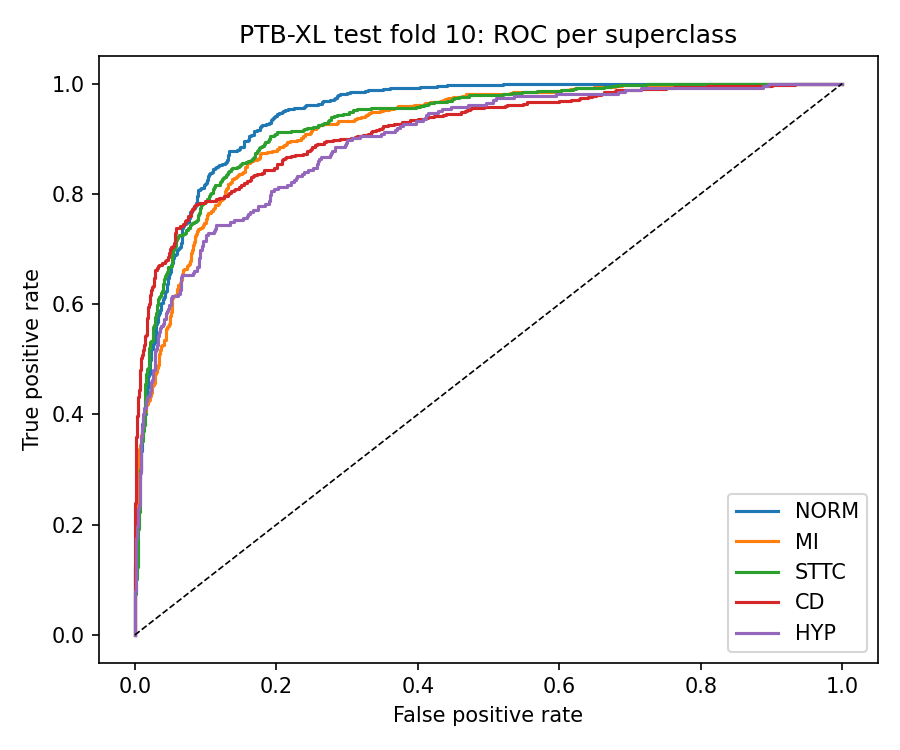

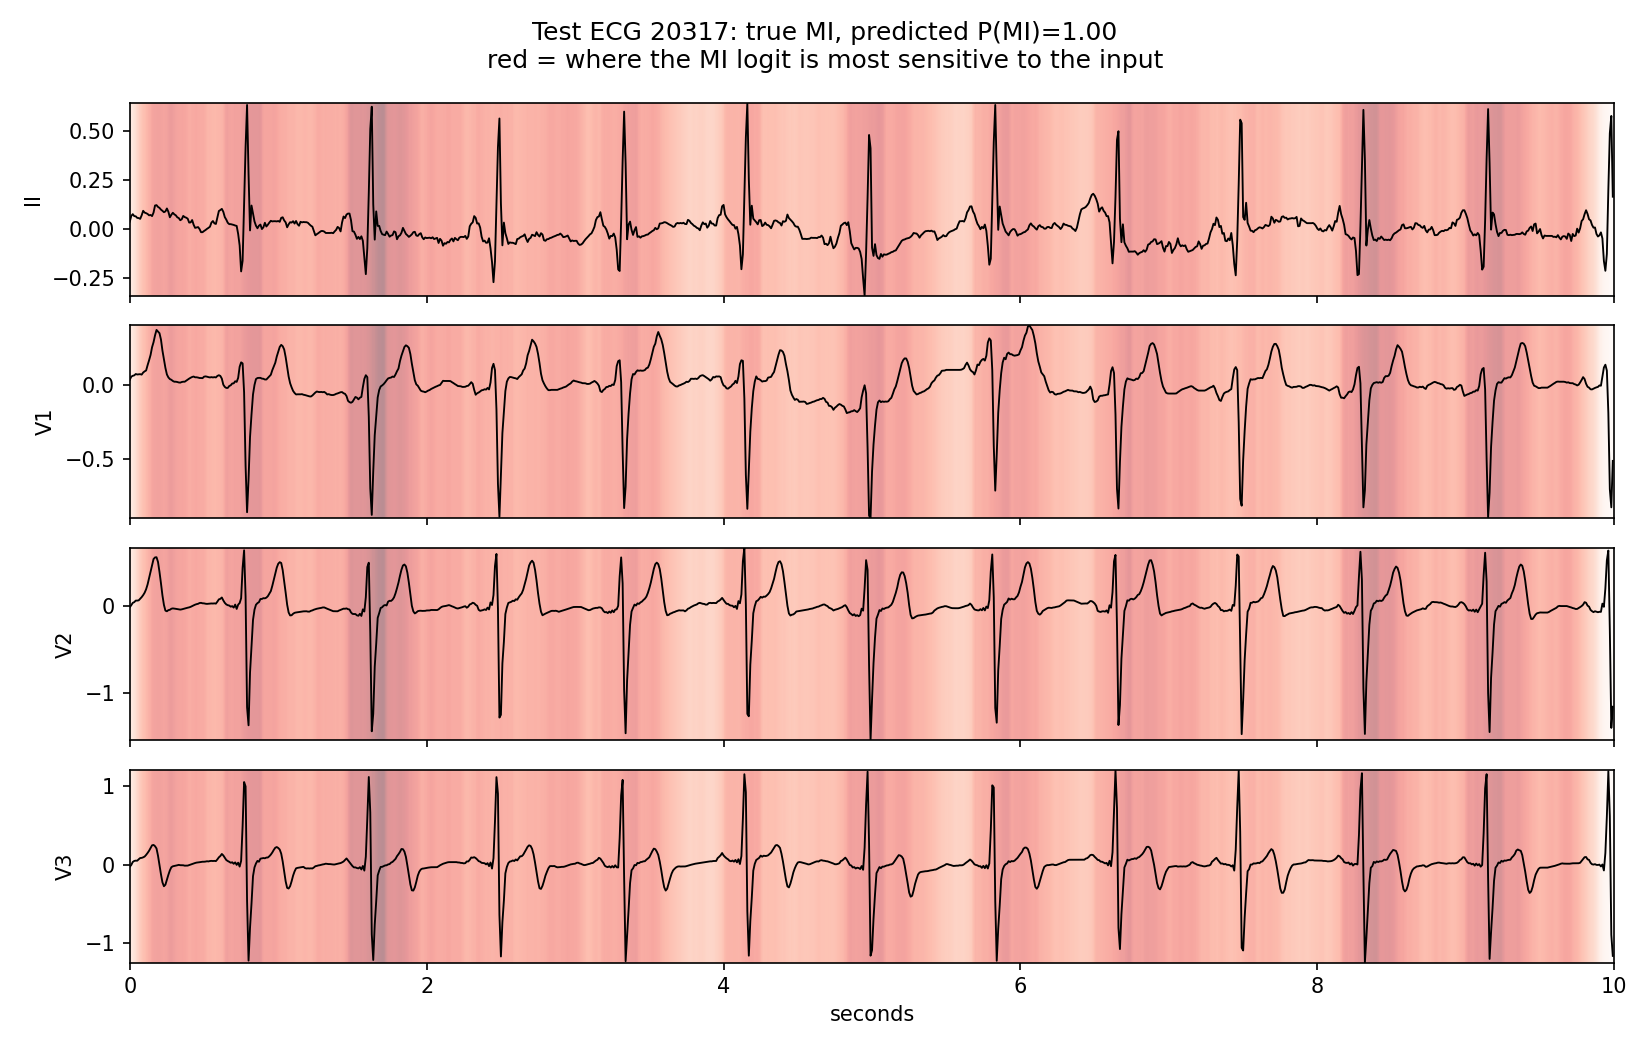

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
%cd /content/MedTech-Suite/day-1-ptbxl-arrhythmia-classifier

# Show results inline so they are saved in this notebook's outputs (works in VS Code and browser Colab)
import json
from IPython.display import Image, display

print(open('results/metrics.json').read()[:1500])
print(open('results/f1_at_0.5.json').read())

display(Image('results/roc.png'))
display(Image('results/saliency_mi.png'))

try:
    !zip -qr results.zip results/metrics.json results/f1_at_0.5.json results/roc.png results/saliency_mi.png
    from google.colab import files; files.download('results.zip')   # browser Colab only
except Exception as e:
    print('download skipped:', e)
